# Exploratory analysis
In this notebook we'll do exploratory analysis of the New York Times Bestseller list data.

## Libraries

In [2]:
"""Here we import the libraries necessary for our EDA process"""
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.ticker import MaxNLocator

In [77]:
import zipfile

## Load the data

In [3]:
df = pd.read_csv('nyt_bestsellers_final.csv')

C:\Users\jbigu\AppData\Local\Temp\ipykernel_4124\844195986.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('nyt_bestsellers_final.csv')


In [ ]:
df.drop_duplicates()

In [44]:
df.drop(columns=('Unnamed: 0'))

,date,list_name,rank,title,author,publisher,weeks_on_list,rank_last_week,isbn13,publishing_group
0,2009-01-04,Hardcover Fiction,1,THE CHRISTMAS SWEATER,GLENN BECK,THRESHOLD EDITIONS,6,2,9781416594857,SIMON & SCHUSTER
1,2009-01-04,Hardcover Fiction,1,THE CHRISTMAS SWEATER,KEVIN BALFE,THRESHOLD EDITIONS,6,2,9781416594857,SIMON & SCHUSTER
2,2009-01-04,Hardcover Fiction,1,THE CHRISTMAS SWEATER,JASON WRIGHT,THRESHOLD EDITIONS,6,2,9781416594857,SIMON & SCHUSTER
3,2009-01-04,Hardcover Fiction,2,SCARPETTA,PATRICIA CORNWELL,PUTNAM,3,1,9780399155161,PENGUIN RANDOM HOUSE
4,2009-01-04,Hardcover Fiction,3,CROSS COUNTRY,JAMES PATTERSON,"LITTLE, BROWN",5,3,9780316018722,HACHETTE
...,...,...,...,...,...,...,...,...,...,...
328044,2025-10-26,Young Adult Paperback,6,IF HE HAD BEEN WITH ME,LAURA NOWLIN,FIRE,34,0,9781728205489.0,SOURCEBOOKS
328045,2025-10-26,Young Adult Paperback,7,LONG LIVE THE PUMPKIN QUEEN,SHEA ERNSHAW,DISNEY,3,0,9781368115988.0,DISNEY
328046,2025-10-26,Young Adult Paperback,8,THAT'S NOT MY NAME,MEGAN LALLY,FIRE,3,0,9781728270111.0,SOURCEBOOKS
328047,2025-10-26,Young Adult Paperback,9,IF ONLY I HAD TOLD HER,LAURA NOWLIN,FIRE,20,0,9781728276229.0,SOURCEBOOKS


In [4]:
# Create the db connection
conn = sqlite3.connect('nyt.db')
df.to_sql('bestsellers', conn, if_exists='replace', index=False)

328049

## Exploratory Data Analysis

### Titles that reached the rank 1 between 2010 and 2020 in Hardcover Fiction

In [45]:
# TITLES THAT REACHED THE #1 PLACE BETWEEN 2010 AND 2020 IN HARDCOVER FICTION
RANK1_QUERY = """
SELECT
  DISTINCT isbn13,
  title,
  author
FROM bestseLlers
WHERE
  date BETWEEN '2010-01-01' AND '2021-01-01'
  AND list_name = 'Hardcover Fiction'
  AND rank = 1
"""
result = pd.read_sql(RANK1_QUERY, conn)
# Print the `result` dataframe
result

,isbn13,title,author
0,9780385533133,THE LOST SYMBOL,DAN BROWN
1,9780385504225,THE LOST SYMBOL,DAN BROWN
2,9780399155345,THE HELP,KATHRYN STOCKETT
3,9780316036221,WORST CASE,JAMES PATTERSON
4,9780316036221,WORST CASE,MICHAEL LEDWIDGE
...,...,...,...
377,9781984818461,THE SENTINEL,ANDREW CHILD
378,9781982154837,FORTUNE AND GLORY,JANET EVANOVICH
379,9780316485623,THE LAW OF INNOCENCE,MICHAEL CONNELLY
380,9780765326386,RHYTHM OF WAR,BRANDON SANDERSON


In [63]:
"""
Here we'll explore the trajectory of each book that reached the #1 rank from the previous query. To do so,
we'll create a tuple with all of the books ISBN, so we can later use the ISBN to read the trajectory of that
specific book.
"""

# Create a tuple with all of the isbn13 of the books that reached rank 1 in the list between 2010 and 2020
# (from the previous query).
# We convert it into a set before converting it into a tuple to remove duplicates (books written by more than one author)
isbn_tuple = tuple(set(result['isbn13'].to_list()))
any(result.duplicated(['isbn13'], keep=False))


# Now, we'll make a query to get the trajectory of all of the books that reached the rank 1

TRAJECTORY_QUERY = f"""
SELECT isbn13, title, author, date, rank
FROM bestsellers
WHERE
  isbn13 IN {isbn_tuple}
  AND list_name = 'Hardcover Fiction'
ORDER BY date
"""

TRAJECTORY_RESULT = pd.read_sql(TRAJECTORY_QUERY, conn)

# Print the resulting dataframe with all of the books trajectories
TRAJECTORY_RESULT

,isbn13,title,author,date,rank
0,9780399155345,THE HELP,KATHRYN STOCKETT,2009-03-01,29
1,9780399155345,THE HELP,KATHRYN STOCKETT,2009-03-08,22
2,9780399155345,THE HELP,KATHRYN STOCKETT,2009-03-15,30
3,9780399155345,THE HELP,KATHRYN STOCKETT,2009-03-22,29
4,9780399155345,THE HELP,KATHRYN STOCKETT,2009-03-29,16
...,...,...,...,...,...
4796,9780525536291,THE VANISHING HALF,BRIT BENNETT,2021-05-09,10
4797,9780525536291,THE VANISHING HALF,BRIT BENNETT,2021-05-16,12
4798,9780525536291,THE VANISHING HALF,BRIT BENNETT,2021-06-13,14
4799,9780525536291,THE VANISHING HALF,BRIT BENNETT,2021-07-11,13


In [64]:
# Convert into datetime the dates from `date` column in our resulting dataframe
TRAJECTORY_RESULT["date"] = pd.to_datetime(TRAJECTORY_RESULT["date"])

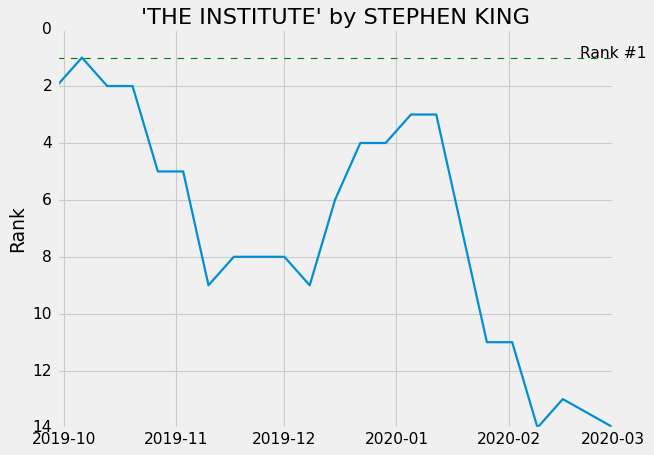

In [67]:
# We'll print the trajectory of a single book that reached the rank 1
# in this case, we'll pick a random book from the isbn tuple (the number of different books is 381).

book_num = 179
book = TRAJECTORY_RESULT[TRAJECTORY_RESULT["isbn13"] == isbn_tuple[book_num]]

# PLOT THE BOOK TRAJECTORY
plt.plot(book["date"], book["rank"], linewidth=2)
plt.style.use('fivethirtyeight')
ax = plt.gca() 

# Invert y-axis because rank #1 is the highest
ax.invert_yaxis()

# Force the y-axis to only use integers
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Date formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

# Titles and text in the graph
plt.title(f"'{book['title'].iloc[0]}' by {book['author'].iloc[0]}")
plt.ylabel('Rank')
plt.axhline(y=1, linestyle="--", color='g', linewidth=1)
plt.text(book["date"].max(), 1.1, 'Rank #1', va='bottom', ha='center')
plt.show()

#### Plotting all the trajectories of the books that reached rank 1 in the list

In [69]:
for num in range(len(isbn_tuple)):
  plt.figure()
  book = TRAJECTORY_RESULT[TRAJECTORY_RESULT["isbn13"] == isbn_tuple[num]]
  span_days = (book["date"].max() - book["date"].min()).days
  rank1 = book[book["rank"] == 1]
  groups = (rank1["date"].diff().dt.days != 7).cumsum()

  plt.plot(book["date"], book["rank"], linewidth=2)

  plt.gca().invert_yaxis()
  plt.style.use('fivethirtyeight')

  for _, g in rank1.groupby(groups):

      start = g["date"].min()
      end = g["date"].max()

      if start == end:
          # Only one week
          plt.axvline(start, linestyle="--", alpha=0.5, linewidth=1,color='g')
      else:
          # Several weeks in a row
          plt.axvspan(start, end, alpha=0.2)

  ax = plt.gca()
  if span_days < 120:  # Less than 4 months
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
  elif span_days < 365:  # Less than a year
      ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
  else:  # more than a year
      ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

  plt.xticks(rotation=45)

  plt.ylabel("Rank")

  plt.title(f"'{book['title'].iloc[0]}' by {book['author'].iloc[0]}")
  plt.suptitle(y=1,t='NYT Hardcover Fiction ranking trajectory: 2010-2015',color='grey')
  plt.axhline(y=1, linestyle="--", color='g', linewidth=1)
  plt.text(book["date"].max(), 1.1, 'Rank #1', va='bottom', ha='center')
  plt.savefig(f"book_{num:03d}.png", dpi=300, bbox_inches="tight")
  plt.close()

In [78]:
with zipfile.ZipFile("book_plots.zip", "w") as z:
    for i in range(len(isbn_tuple)):
        z.write(f"book_{i:03d}.png")